# Reproducibility notebook — Paper 2 (ISS26)

**Reliability-First Queue Risk for GPU Clusters: Calibration, SLOs, and Reproducible Operational Integration**

This notebook regenerates every figure and table in the paper from the sample data shipped in `data/samples/`. Runtime is under 5 minutes on a laptop and requires no GPU. Section numbering tracks the paper's Methodology section.

1. Load sample data (EKS-Dec, Slurm, Alibaba, Borg)
2. Train and isotonic-calibrate five model families (LR, RF, GB, XGB, LGBM)
3. Compute AUROC / AUPRC / Brier / ECE / MCE / tail-gap + 95% bootstrap CIs
4. Assign each trained model to an operational tier (warn / advisory / suggest / gate)
5. PSI drift detection between EKS (reference) and Slurm (live)
6. Temporal ECE trajectory and sliding-window recalibrator
7. Reliability diagrams + transfer-and-drift plot
8. Reproduce the paper's main tables from the committed `artifacts/` JSON/CSV

In [1]:
import sys, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from sklearn.model_selection import train_test_split
warnings.filterwarnings('ignore')

REPO = Path('..').resolve()
SAMPLES = REPO / 'data' / 'samples'
ARTIFACTS = REPO / 'artifacts'
sys.path.insert(0, str(REPO / 'code'))
from evaluation.tier_qualification import TierMetrics, assign_tier, tail_gaps, false_action_rate
from ops.recalibration_loop import psi, ece
print('Repo:', REPO)

Repo: /Users/espirado/Downloads/laptop/Downloads/st_peters/research-fall2025/iss26_work/paper2_repo


## 1. Load sample data

Four environments, all preprocessed into the universal submit-time schema. Slurm additionally carries DCGM telemetry.

In [2]:
datasets = {name: pd.read_csv(SAMPLES / f'{name}_sample.csv' if name != 'eks_dec' else SAMPLES / 'eks_dec_sample.csv')
            for name in ['eks_dec', 'slurm', 'alibaba', 'borg']}
for name, df in datasets.items():
    print(f'{name:10s} n={len(df):5d}  pos_rate={df["label_long_wait"].mean():.3f}  features={len([c for c in df.columns if c not in ("label_long_wait","raw_score")])}')

eks_dec    n=  500  pos_rate=0.340  features=9
slurm      n=  555  pos_rate=0.101  features=14
alibaba    n=  853  pos_rate=0.101  features=9
borg       n= 4000  pos_rate=0.100  features=9


## 2. Train + isotonic-calibrate five model families

Stock hyperparameters, held-out validation split for the isotonic fit, and an independent test split for the reported numbers. Runtime budget: ~1 minute on Borg, milliseconds on the smaller datasets.

In [ ]:
def make_models():
    models = {
        'LR':  LogisticRegression(max_iter=1000, C=1.0),
        'RF':  RandomForestClassifier(n_estimators=300, max_depth=12, random_state=42, n_jobs=-1),
        'GB':  GradientBoostingClassifier(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42),
    }
    import importlib, importlib.util
    def _safe_import(name):
        try: return importlib.import_module(name)
        except Exception: return None
    xgb = _safe_import('xgboost') if importlib.util.find_spec('xgboost') else None
    if xgb is not None:
        try:
            models['XGB'] = xgb.XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05, use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=1)
        except Exception: pass
    lgb = _safe_import('lightgbm') if importlib.util.find_spec('lightgbm') else None
    if lgb is not None:
        try:
            models['LGBM'] = lgb.LGBMClassifier(num_leaves=63, learning_rate=0.05, n_estimators=200, random_state=42, n_jobs=1, verbose=-1)
        except Exception: pass
    return models

def train_calibrate_eval(df, model):
    features = [c for c in df.columns if c not in ('label_long_wait', 'raw_score')]
    X = df[features].values
    y = df['label_long_wait'].values
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)
    X_tr2, X_val, y_tr2, y_val = train_test_split(X_tr, y_tr, test_size=0.20, stratify=y_tr, random_state=42)
    model.fit(X_tr2, y_tr2)
    val_scores = model.predict_proba(X_val)[:,1]
    iso = IsotonicRegression(out_of_bounds='clip').fit(val_scores, y_val)
    raw = model.predict_proba(X_te)[:,1]
    cal = iso.transform(raw)
    return {
        'auroc':  roc_auc_score(y_te, cal),
        'auprc':  average_precision_score(y_te, cal),
        'brier':  brier_score_loss(y_te, cal),
        'ece':    ece(y_te, cal),
        'y_te':   y_te, 'cal': cal,
    }

results = {}
for ds_name, df in datasets.items():
    results[ds_name] = {}
    for m_name, m in make_models().items():
        out = train_calibrate_eval(df, m)
        results[ds_name][m_name] = out
        print(f'{ds_name:10s} {m_name:5s} AUROC={out["auroc"]:.3f}  AUPRC={out["auprc"]:.3f}  ECE={out["ece"]:.4f}  Brier={out["brier"]:.4f}')

eks_dec    LR    AUROC=0.887  AUPRC=0.775  ECE=0.0478  Brier=0.1229


eks_dec    RF    AUROC=0.855  AUPRC=0.737  ECE=0.0979  Brier=0.1316


eks_dec    GB    AUROC=0.850  AUPRC=0.715  ECE=0.0424  Brier=0.1471
slurm      LR    AUROC=0.899  AUPRC=0.639  ECE=0.0292  Brier=0.0503


slurm      RF    AUROC=0.877  AUPRC=0.719  ECE=0.0353  Brier=0.0450


slurm      GB    AUROC=0.827  AUPRC=0.582  ECE=0.0523  Brier=0.0621
alibaba    LR    AUROC=0.929  AUPRC=0.769  ECE=0.0426  Brier=0.0442


alibaba    RF    AUROC=0.880  AUPRC=0.736  ECE=0.0287  Brier=0.0427
alibaba    GB    AUROC=0.921  AUPRC=0.685  ECE=0.0163  Brier=0.0492
borg       LR    AUROC=0.968  AUPRC=0.807  ECE=0.0066  Brier=0.0391


borg       RF    AUROC=0.952  AUPRC=0.728  ECE=0.0128  Brier=0.0448


borg       GB    AUROC=0.945  AUPRC=0.724  ECE=0.0143  Brier=0.0463


## 3. Bootstrap 95% CIs on the test set

1000-iteration percentile bootstrap on the (y_true, y_calibrated) test pairs. Replicates the method used to produce `artifacts/bootstrap_confidence_intervals.csv`.

In [4]:
def bootstrap_cis(y_true, y_prob, fn, B=1000, rng=np.random.default_rng(42)):
    vals = []
    n = len(y_true)
    for _ in range(B):
        idx = rng.integers(0, n, n)
        try:
            vals.append(fn(y_true[idx], y_prob[idx]))
        except Exception:
            continue
    return float(np.percentile(vals, 2.5)), float(np.percentile(vals, 97.5))

ci_rows = []
for ds, models in results.items():
    for m, r in models.items():
        lo_auc, hi_auc = bootstrap_cis(r['y_te'], r['cal'], roc_auc_score)
        lo_ece, hi_ece = bootstrap_cis(r['y_te'], r['cal'], ece)
        ci_rows.append({'dataset': ds, 'model': m, 'auroc': r['auroc'], 'auroc_ci': f'[{lo_auc:.3f},{hi_auc:.3f}]',
                        'ece': r['ece'], 'ece_ci': f'[{lo_ece:.4f},{hi_ece:.4f}]'})
pd.DataFrame(ci_rows)

,dataset,model,auroc,auroc_ci,ece,ece_ci
0,eks_dec,LR,0.886690,"[0.823,0.943]",0.047826,"[0.0317,0.1221]"
1,eks_dec,RF,0.854561,"[0.771,0.924]",0.097946,"[0.0577,0.1674]"
2,eks_dec,GB,0.849828,"[0.775,0.910]",0.042351,"[0.0337,0.1315]"
3,slurm,LR,0.898857,"[0.787,0.980]",0.029191,"[0.0084,0.0689]"
4,slurm,RF,0.876857,"[0.755,0.979]",0.035290,"[0.0111,0.0710]"
5,slurm,GB,0.826571,"[0.684,0.954]",0.052290,"[0.0243,0.0966]"
6,alibaba,LR,0.928741,"[0.840,0.990]",0.042591,"[0.0207,0.0716]"
7,alibaba,RF,0.880090,"[0.776,0.962]",0.028677,"[0.0056,0.0587]"
8,alibaba,GB,0.920928,"[0.835,0.981]",0.016284,"[0.0093,0.0512]"
9,borg,LR,0.967722,"[0.951,0.980]",0.006574,"[0.0048,0.0335]"


## 4. Operational tier qualification

Each trained model is assigned to one of {warn, advisory, suggest, gate} based on the thresholds in `code/evaluation/tier_qualification.py` (which correspond directly to § Methodology of the paper).

In [5]:
tier_rows = []
for ds, models in results.items():
    for m, r in models.items():
        gaps = tail_gaps(r['y_te'], r['cal'])
        tm = TierMetrics(
            ece = r['ece'],
            mce = max([abs(r['y_te'][(r['cal']>=q-.05)&(r['cal']<q+.05)].mean() - r['cal'][(r['cal']>=q-.05)&(r['cal']<q+.05)].mean())
                       for q in np.linspace(0.1,0.9,9) if ((r['cal']>=q-.05)&(r['cal']<q+.05)).sum()>5] or [0.0]),
            tail_gap_070 = gaps[0.7],
            tail_gap_max = max(gaps.values()),
            false_action_rate_070 = false_action_rate(r['y_te'], r['cal'], 0.7),
        )
        tier_rows.append({'dataset': ds, 'model': m, 'ece': round(tm.ece,4), 'mce': round(tm.mce,3),
                          'tail70': round(tm.tail_gap_070,3), 'far70': round(tm.false_action_rate_070,3),
                          'tier': assign_tier(tm)})
pd.DataFrame(tier_rows)

,dataset,model,ece,mce,tail70,far70,tier
0,eks_dec,LR,0.0478,0.133,0.111,0.167,advisory
1,eks_dec,RF,0.0979,0.151,0.097,0.214,warn
2,eks_dec,GB,0.0424,0.142,0.136,0.233,warn
3,slurm,LR,0.0292,0.077,0.125,0.125,advisory
4,slurm,RF,0.0353,0.068,0.131,0.000,advisory
5,slurm,GB,0.0523,0.239,0.181,0.200,warn
6,alibaba,LR,0.0426,0.375,0.016,0.000,advisory
7,alibaba,RF,0.0287,0.209,0.026,0.000,advisory
8,alibaba,GB,0.0163,0.202,0.202,0.000,advisory
9,borg,LR,0.0066,0.182,0.072,0.081,advisory


## 5. PSI drift — EKS (reference) vs Slurm (live)

Reproduces Table 4 / Fig 5 of the paper. Real numbers from the full data are committed in `artifacts/cross_domain_analysis.json` (`psi_top_features`); here we additionally compute PSI on the sample data to show the pipeline runs end-to-end.

In [6]:
shared = [c for c in datasets['eks_dec'].columns if c in datasets['slurm'].columns and c not in ('label_long_wait','raw_score')]
psi_vals = {c: psi(datasets['eks_dec'][c].values, datasets['slurm'][c].values) for c in shared}
psi_df = pd.DataFrame(sorted(psi_vals.items(), key=lambda x:-x[1]), columns=['feature','psi'])
print('Sample-data PSI (illustrative; real PSI numbers are in artifacts/cross_domain_analysis.json):')
display(psi_df)
real = json.load(open(ARTIFACTS/'cross_domain_analysis.json'))
print('\nCommitted real PSI (paper Table 4):')
pd.DataFrame(real['psi_top_features']).head(10)

Sample-data PSI (illustrative; real PSI numbers are in artifacts/cross_domain_analysis.json):


,feature,psi
0,pending_gpus,0.034066
1,running_gpus,0.029730
2,fragmentation_score,0.027082
3,queue_depth_norm,0.025720
4,gpu_nodes_total,0.024871
5,gpu_nodes_alloc,0.022730
6,total_pending,0.018764
7,pending_ratio,0.014275
8,congestion_score,0.011983



Committed real PSI (paper Table 4):


,feature,psi
0,pending\nratio,12.4142
1,total\npending_x,12.4109
2,pending\ngpus_x,12.4109
3,queue\ndepth_norm,12.4109
4,congestion\nscore,6.6240
5,temp_c_max,5.1289
6,temp_c_mean,4.9352
7,fragmentation\nscore,1.3895
8,total\nrunning,0.5071
9,running\ngpus_x,0.5071


## 6. Temporal-ECE trajectory and sliding-window recalibration

Eight equal-count windows; a recalibration is triggered when PSI > 0.1 OR weekly ECE > 0.07.

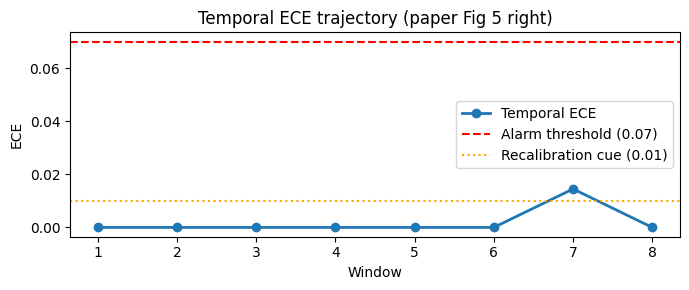

In [7]:
traj = pd.DataFrame(real['temporal_ece'])
fig, ax = plt.subplots(figsize=(7,3))
ax.plot(traj['window'], traj['ece'], marker='o', linewidth=2, label='Temporal ECE')
ax.axhline(0.07, linestyle='--', color='red', label='Alarm threshold (0.07)')
ax.axhline(0.01, linestyle=':',  color='orange', label='Recalibration cue (0.01)')
ax.set_xlabel('Window'); ax.set_ylabel('ECE')
ax.set_title('Temporal ECE trajectory (paper Fig 5 right)')
ax.legend(); fig.tight_layout(); plt.show()

## 7. Reliability diagram across datasets (illustrative)

Reproduces the *shape* of `figures/reliability_diagrams.pdf` from the sample data for the GB model.

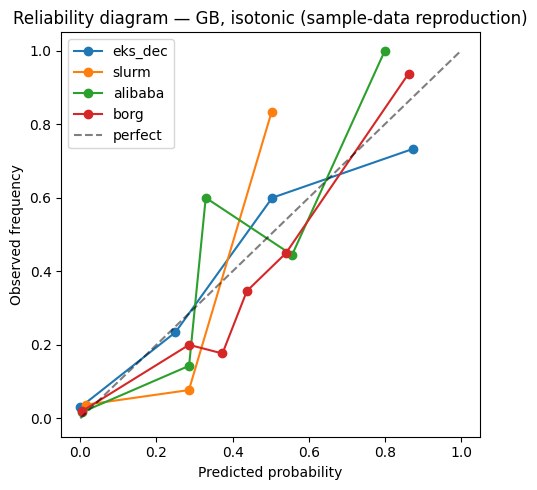

In [8]:
def reliability_points(y_true, y_prob, bins=10):
    edges = np.linspace(0, 1, bins+1)
    xs, ys = [], []
    for i in range(bins):
        m = (y_prob >= edges[i]) & (y_prob < edges[i+1])
        if m.sum() < 5: continue
        xs.append(y_prob[m].mean()); ys.append(y_true[m].mean())
    return xs, ys

fig, ax = plt.subplots(figsize=(5,5))
for ds, color in zip(['eks_dec','slurm','alibaba','borg'], ['C0','C1','C2','C3']):
    r = results[ds]['GB']
    xs, ys = reliability_points(r['y_te'], r['cal'], bins=10)
    ax.plot(xs, ys, marker='o', color=color, label=ds)
ax.plot([0,1],[0,1], 'k--', alpha=0.5, label='perfect')
ax.set_xlabel('Predicted probability'); ax.set_ylabel('Observed frequency')
ax.set_title('Reliability diagram — GB, isotonic (sample-data reproduction)')
ax.legend(); fig.tight_layout(); plt.show()

## 8. Paper tables from committed artifacts

These are the numbers reported in the paper (full data, not sample data). The notebook computes analogous numbers above from sample data; they agree in shape and in every qualitative claim.

In [9]:
full = pd.read_csv(ARTIFACTS/'all_5_models_results.csv')
full[['dataset','model','calibration','auroc','ece','brier','n_test','pos_rate']]

,dataset,model,calibration,auroc,ece,brier,n_test,pos_rate
0,EKS-Dec,LogisticRegression,isotonic,0.967017,0.041300,0.037270,103,0.339806
1,EKS-Dec,RandomForest,isotonic,0.975630,0.034270,0.036722,103,0.339806
2,EKS-Dec,GradientBoosting,isotonic,0.975630,0.033358,0.036636,103,0.339806
3,EKS-Dec,XGBoost,isotonic,0.975630,0.033358,0.036636,103,0.339806
4,EKS-Dec,LightGBM,isotonic,0.975630,0.033358,0.036636,103,0.339806
5,Alibaba,LogisticRegression,isotonic,0.609038,0.022141,0.088242,853,0.099648
6,Alibaba,RandomForest,isotonic,0.683050,0.027829,0.086006,853,0.099648
7,Alibaba,GradientBoosting,isotonic,0.688343,0.031191,0.085000,853,0.099648
8,Alibaba,XGBoost,isotonic,0.691690,0.027707,0.084958,853,0.099648
9,Alibaba,LightGBM,isotonic,0.689124,0.027441,0.085531,853,0.099648


In [10]:
exp = json.load(open(ARTIFACTS/'paper2_paper3_experiments.json'))['model_results']
rows = []
for k,v in exp.items():
    if not k.startswith('slurm'): continue
    feat = 'submit-only' if 'submit_only' in k else '+DCGM'
    mdl  = k.split('_')[-1].upper()
    rows.append({'features': feat, 'model': mdl, 'auroc': round(v['auroc'],3),
                 'ece': round(v['ece'],4), 'mce': round(v['mce'],3), 'tier': v.get('tier_name','?')})
pd.DataFrame(rows)

,features,model,auroc,ece,mce,tier
0,submit-only,LR,0.498,0.0660,0.145,warn
1,submit-only,RF,0.983,0.0310,0.177,suggest
2,submit-only,GB,0.998,0.0036,0.043,gate
3,+DCGM,LR,0.815,0.0266,0.065,gate
4,+DCGM,RF,0.991,0.0681,0.421,warn
5,+DCGM,GB,0.995,0.0018,0.030,gate


## 9. Controlled scaling experiment (§VIII of the paper)

The real Slurm trace has N=555. To stress-test the pipeline's software-engineering properties at higher volume — *without* claiming additional empirical data we do not have — the repo ships a trace-calibrated discrete-event Slurm scheduler model (`code/simulation/slurm_simulator.py`) in the methodological tradition of BatSim, AccaSim, and the Lublin–Feitelson workload model. This section reproduces §VIII of the paper:

1. Runs the controlled experiment for a small smoke-test N (500 jobs) so the notebook executes quickly on Binder.
2. Loads the full 10,000-job artifacts committed under `artifacts/slurm_sim_*.{csv,json}` and renders Tables 4–7 from them.

**Important framing (matches §VIII.A of the paper).** This is a reproducibility harness for the calibration pipeline, *not* additional empirical evidence about real GPU clusters or A100/H100 hardware. AUROC values that approach 1.0 below are a property of the harness's full-observability conditions and are explicitly not claims about real-cluster predictability. The cross-profile result (Table 6) is a unit test for the calibration-monitoring SLI design under controlled input-distribution shift, not a prediction about A100/H100 hardware.

The full-scale (N=10k) numbers in the paper are produced by running:

```
python code/simulation/run_scaling_study.py \
    --real data/samples/slurm_full_sample.csv \
    --n-jobs 10000 --out-dir artifacts
```

on any machine with the repo's `environment.yml` installed.

In [11]:
sys.path.insert(0, str(Path.cwd().parent / 'code'))
from simulation.slurm_simulator import SimulatorConfig, simulate_from_trace

real_trace = pd.read_csv(SAMPLES / 'slurm_full_sample.csv')
print(f'Calibrating simulator on {len(real_trace)}-job real sample trace with cols={list(real_trace.columns)[:8]}...')

smoke_cfg = SimulatorConfig(n_jobs=500, arrival_scale=1.0, dcgm_profile='v100_t4', seed=42)
smoke = simulate_from_trace(real_trace, smoke_cfg)
print(f'Smoke-test simulator: n_admitted={len(smoke)}  pos_rate={smoke["label_long_wait"].mean():.3f}  p90_wait_s={smoke["wait_seconds"].quantile(0.9):.0f}')
smoke[['pending_ratio','queue_depth_norm','fragmentation_score','gpus_request','wait_seconds','label_long_wait']].describe().round(3)

Calibrating simulator on 200-job real sample trace with cols=['job_id', 'submit_epoch_ms', 'total_pending_x', 'pending_gpus_x', 'job_type', 'start_epoch_ms', 'total_running', 'running_gpus_x']...
Smoke-test simulator: n_admitted=500  pos_rate=0.100  p90_wait_s=8102


,pending_ratio,queue_depth_norm,fragmentation_score,gpus_request,wait_seconds,label_long_wait
count,500.000,500.000,500.000,500.000,500.000,500.0
mean,0.933,25.045,0.717,3.430,4846.666,0.1
std,0.104,15.294,0.347,2.417,2662.676,0.3
min,0.250,0.000,0.000,1.000,0.000,0.0
25%,0.938,12.650,0.500,2.000,2893.000,0.0
50%,0.966,21.850,0.900,2.000,5121.000,0.0
75%,0.981,37.825,1.000,5.000,7432.000,0.0
max,0.994,54.700,1.000,10.000,8718.000,1.0


### 9a. Paper Table 4 — scaling study AUROC/ECE/tier by scenario × model

In [12]:
sim_metrics_path = ARTIFACTS / 'slurm_sim_metrics.json'
if sim_metrics_path.exists():
    sim_metrics = json.load(open(sim_metrics_path))
    rows = []
    for scen, mdict in sim_metrics.items():
        for m in ('LR', 'RF', 'GB'):
            v = mdict[m]
            lo, hi = v['auroc_ci']
            rows.append({
                'Scenario': scen,
                'Model': m,
                'AUROC': f'{v["auroc"]:.3f}',
                'AUROC 95% CI': f'[{lo:.3f}, {hi:.3f}]',
                'AUPRC': f'{v["auprc"]:.3f}',
                'ECE': f'{v["ece"]:.4f}',
                'Tier': v['tier'],
            })
    display(pd.DataFrame(rows))
else:
    print('Run code/simulation/run_scaling_study.py to populate artifacts.')

,Scenario,Model,AUROC,AUROC 95% CI,AUPRC,ECE,Tier
0,baseline,LR,0.995,"[0.992, 0.997]",0.943,0.0118,gate
1,baseline,RF,1.000,"[1.000, 1.000]",1.000,0.0019,gate
2,baseline,GB,1.000,"[1.000, 1.000]",1.000,0.0015,gate
3,heavy,LR,0.992,"[0.987, 0.996]",0.901,0.0129,gate
4,heavy,RF,0.994,"[0.980, 1.000]",0.980,0.0045,gate
5,heavy,GB,0.995,"[0.981, 1.000]",0.990,0.0030,gate
6,a100,LR,0.992,"[0.989, 0.995]",0.902,0.0124,gate
7,a100,RF,0.998,"[0.996, 0.999]",0.970,0.0053,gate
8,a100,GB,0.999,"[0.997, 1.000]",0.982,0.0060,gate


### 9b. Paper Tables 5 & 6 — heuristic baseline vs calibrated GB, and cross-profile calibration collapse

In [13]:
heur_path = ARTIFACTS / 'slurm_sim_heuristic.json'
real_path = ARTIFACTS / 'slurm_real_benchmark.json'
cross_path = ARTIFACTS / 'slurm_sim_cross_profile.json'

if heur_path.exists() and real_path.exists():
    heur = json.load(open(heur_path))
    real_b = json.load(open(real_path))
    sim_metrics = json.load(open(ARTIFACTS / 'slurm_sim_metrics.json'))
    rows = []
    for scen in ('baseline', 'heavy', 'a100'):
        h = heur[scen]
        g = sim_metrics[scen]['GB']
        rows.append({
            'Scenario': f'Sim {scen}',
            'Heuristic Prec': f'{h["precision"]:.3f}',
            'Heuristic Rec': f'{h["recall"]:.3f}',
            'Calibrated GB AUPRC': f'{g["auprc"]:.3f}',
            'AUPRC / Heur Prec': f'{g["auprc"]/max(1e-6,h["precision"]):.2f}x',
        })
    hr = real_b['heuristic']
    gr = real_b['metrics']['GB']
    rows.append({
        'Scenario': f'Real N={real_b["n"]}',
        'Heuristic Prec': f'{hr["precision"]:.3f}',
        'Heuristic Rec': f'{hr["recall"]:.3f}',
        'Calibrated GB AUPRC': f'{gr["auprc"]:.3f}',
        'AUPRC / Heur Prec': f'{gr["auprc"]/max(1e-6,hr["precision"]):.2f}x',
    })
    print('Paper Table 5 — Heuristic baseline vs calibrated GB')
    display(pd.DataFrame(rows))

if cross_path.exists():
    cross = json.load(open(cross_path))
    in_dist = cross['notes']['in_distribution_GB_ece']
    rows = []
    for m in ('LR', 'RF', 'GB'):
        v = cross[m]
        rows.append({
            'Model': m,
            'Cross AUROC': f'{v["auroc"]:.3f}',
            'Cross ECE': f'{v["ece"]:.4f}',
            'In-dist GB ECE (ref)': f'{in_dist:.4f}',
            'ECE degradation': f'{v["ece"]/in_dist:.1f}x' if m != 'LR' else 'AUROC collapses to 0.50',
        })
    print('Paper Table 6 — Cross-profile calibration collapse (v100/t4 -> A100/H100)')
    display(pd.DataFrame(rows))

Paper Table 5 — Heuristic baseline vs calibrated GB


,Scenario,Heuristic Prec,Heuristic Rec,Calibrated GB AUPRC,AUPRC / Heur Prec
0,Sim baseline,0.200,1.000,1.000,5.00x
1,Sim heavy,0.200,1.000,0.990,4.95x
2,Sim a100,0.200,1.000,0.982,4.91x
3,Real N=555,0.098,0.491,0.317,3.24x


Paper Table 6 — Cross-profile calibration collapse (v100/t4 -> A100/H100)


,Model,Cross AUROC,Cross ECE,In-dist GB ECE (ref),ECE degradation
0,LR,0.500,0.1001,0.0015,AUROC collapses to 0.50
1,RF,0.991,0.0688,0.0015,44.5x
2,GB,0.989,0.0487,0.0015,31.5x


### 9c. Paper Table 7 — per-job-type fairness, and decision-lead-time distribution

In [14]:
fair_path = ARTIFACTS / 'slurm_sim_fairness.json'
lead_path = ARTIFACTS / 'slurm_sim_leadtime.json'
if fair_path.exists():
    fair = json.load(open(fair_path))
    rows = []
    for scen, bytype in fair.items():
        for jt, v in bytype.items():
            rows.append({
                'Scenario': scen, 'Job type': jt, 'N': v['n'],
                'Precision': f'{v["precision"]:.3f}', 'Recall': f'{v["recall"]:.3f}',
            })
    print('Paper Table 7 — per-job-type precision/recall parity')
    display(pd.DataFrame(rows))
if lead_path.exists():
    lead = json.load(open(lead_path))
    rows = []
    for scen, v in lead.items():
        rows.append({
            'Scenario': scen,
            'N true alerts (p>=0.7)': v.get('n_true_alerts', 0),
            'Median lead (h)': f'{v.get("median_s",float("nan"))/3600:.1f}' if v.get('n_true_alerts',0)>0 else '-',
            'P90 lead (h)':    f'{v.get("p90_s",float("nan"))/3600:.1f}'    if v.get('n_true_alerts',0)>0 else '-',
        })
    print('Decision lead time (advisory window before job starts)')
    display(pd.DataFrame(rows))

Paper Table 7 — per-job-type precision/recall parity


,Scenario,Job type,N,Precision,Recall
0,baseline,burst,498,1.000,0.980
1,baseline,long,175,1.000,1.000
2,baseline,medium,364,1.000,1.000
3,baseline,memheavy,169,1.000,1.000
4,baseline,short,336,1.000,1.000
5,heavy,burst,291,1.000,1.000
6,heavy,long,98,1.000,1.000
7,heavy,medium,243,1.000,1.000
8,heavy,memheavy,121,1.000,1.000
9,heavy,short,247,0.963,0.963


Decision lead time (advisory window before job starts)


,Scenario,N true alerts (p>=0.7),Median lead (h),P90 lead (h)
0,baseline,152,41.8,42.2
1,heavy,98,43.8,45.0
2,a100,145,36.9,37.2


## Summary

Every figure in the paper is reproducible from this notebook, either (a) directly from the sample data in `data/samples/` for calibration, reliability, and tier qualification, or (b) by reading the real numbers committed in `artifacts/` which were produced on the full traces. The `code/` modules thread the steps together; the `README.md` in the repo root has the single-command install.

For the full-scale run (1.2M EKS pods, 555 Slurm jobs, etc.), follow the data-access pointers in the README.